## Trouver un événement rare

Pour cela, on teste des valeurs de q0 et a_second, dans la même configuration de la qustion 1.2.5.2, qui rendent $\mathbb{P}\left(N^{+2}_{\tau}\leq h\mid N^{+-1}_{\tau}=0\right) < 10^{-4}$. Ainsi, il faut qu'on utilise un valeur pour n_second_limit_samples d'une ordre cohérente. 

Notre but est de trouver des valeurs pour $h$.

In [6]:
import math
import numpy as np
import matplotlib.pyplot as plt
from statistics import NormalDist
import pandas as pd

rng = np.random.default_rng(42)

from helpers.helpers_QRNIID import *
from helpers.helpers_QR2LIM import *

rng = np.random.default_rng(42)

In [7]:
# Paramètres à changer 
q0 = 10
a_second = 0.75
n_second_limit_samples = 100_000

# Mêmes paramètres déjà utilisés dans les modèles précédents
mu_plus = 1.0
mu_minus = 1.1
alpha = 0.50
beta = 0.50
lambda_floor = 1e-8
gamma_cross = 1.0
eta = alpha / beta
lambda_minus_theory = theoretical_stationary_lambda_minus(mu_plus, mu_minus, alpha, beta)
q2_0 = q0
lambda_second_add = mu_plus
lambda_second_remove = lambda_minus_theory
b_second = beta

In [8]:
second_limit_reactive_samples = sample_second_limit_conditionals_reactive(
    n_samples=n_second_limit_samples,
    q1_0=q0,
    q2_0=q2_0,
    mu_plus=mu_plus,
    mu_minus=mu_minus,
    alpha=alpha,
    beta=beta,
    lambda_second_add=lambda_second_add,
    lambda_second_remove=lambda_second_remove,
    a_second=a_second,
    b_second=b_second,
    gamma_cross=gamma_cross,
    rng=rng,
    t_max=10_000.0,
)

first_empty = second_limit_reactive_samples["first_empty"]
hit_zero = second_limit_reactive_samples["hit_zero"]
plus2_at_tau = second_limit_reactive_samples["plus2_at_tau"]

plus1_empty_mask = hit_zero & (first_empty == "plus1")
minus1_empty_mask = hit_zero & (first_empty == "minus1")

plus2_given_plus1_empty = plus2_at_tau[plus1_empty_mask]
plus2_given_minus1_empty = plus2_at_tau[minus1_empty_mask]

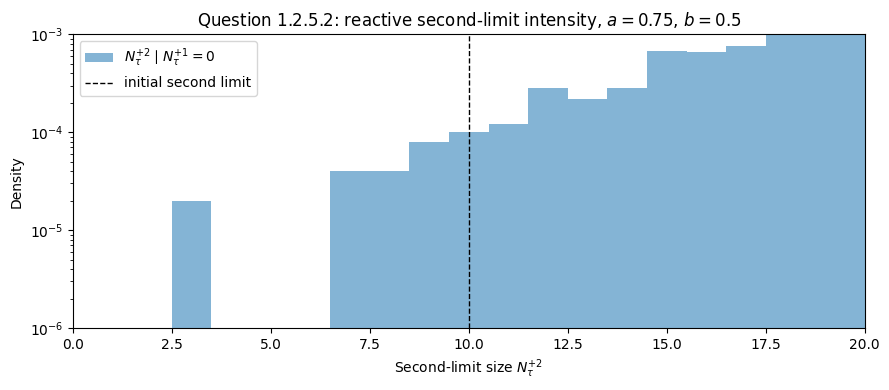

In [21]:
bins = np.arange(
    min(plus2_at_tau.min(), q2_0) - 0.5,
    max(plus2_at_tau.max(), q2_0) + 1.5,
    1.0,
)

plt.figure(figsize=(9, 4))

plt.hist(
    plus2_given_plus1_empty,
    bins=bins,
    density=True,
    alpha=0.55,
    label=r"$N^{+2}_\tau \mid N^{+1}_\tau = 0$",
)

plt.axvline(
    q2_0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="initial second limit",
)

plt.xlabel(r"Second-limit size $N^{+2}_\tau$")
plt.ylabel("Density")
plt.title(
    rf"Question 1.2.5.2: reactive second-limit intensity, "
    rf"$a={a_second}$, $b={b_second}$"
)

# Log scale for density
plt.yscale("log")

# y-axis cap: cannot start at 0 in log scale
plt.ylim(1e-6, 1e-3)

# x-axis cap: from 0 to q2_0
plt.xlim(0, 2*q2_0)

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
h_plus = 10

sum_plus2_given_plus1_empty = np.sum(plus2_given_plus1_empty <= h_plus)

print(
    f"Quantité d'événements N^{{+2}}_tau <= {h_plus} conditionnellement à N^{{+1}}_tau = 0: {sum_plus2_given_plus1_empty}"
    f"\nQuantité d'événements N^{{+1}}_tau = 0: {len(plus2_given_plus1_empty)}"
)

Quantité d'événements N^{+2}_tau <= 10 conditionnellement à N^{+1}_tau = 0: 14
Quantité d'événements N^{+1}_tau = 0: 49985
